[70.70597593, 70.87412572, 74.93944162, 78.26515891, 77.31254315, 76.71850903, 78.19037963, 77.1106216, 76.83279819, 78.37513373, 77.344081, 73.82370969, 74.60092514, 74.81461846, 73.77740314, 74.72888683, 74.95231643, 73.82439125, 71.83458685, 74.41565601, 68.92691842, 70.2920207, 71.89858577, 74.39967605, 70.30626509, 71.84592776, 74.24074149, 70.30669861, 75.1207285, 76.41209318, 72.48205134, 70.89617898, 74.5825953, 76.26024405, 72.40434484, 74.67858009, 76.40893312, 72.44387079, 69.81956602, 70.11656415, 68.55140801, 69.93128079, 71.12978994, 70.01569179, 68.53102848, 69.9597279, 70.14294739, 68.52961669, 74.61059016, 75.06345196, 73.99347028, 74.49868046, 74.80168279, 69.01164414, 73.89539893, 74.63371687, 75.07764241, 73.99275813, 72.95567929, 75.92505121, 71.17774399, 73.09390556, 75.43082196, 71.37979036, 70.6528533, 72.95409725, 75.18434353, 71.21065195, 76.73997479, 78.67343827, 76.79142067, 76.664466, 78.55147954, 76.55951532, 76.76263039, 70.90654269, 78.71177762, 76.79624

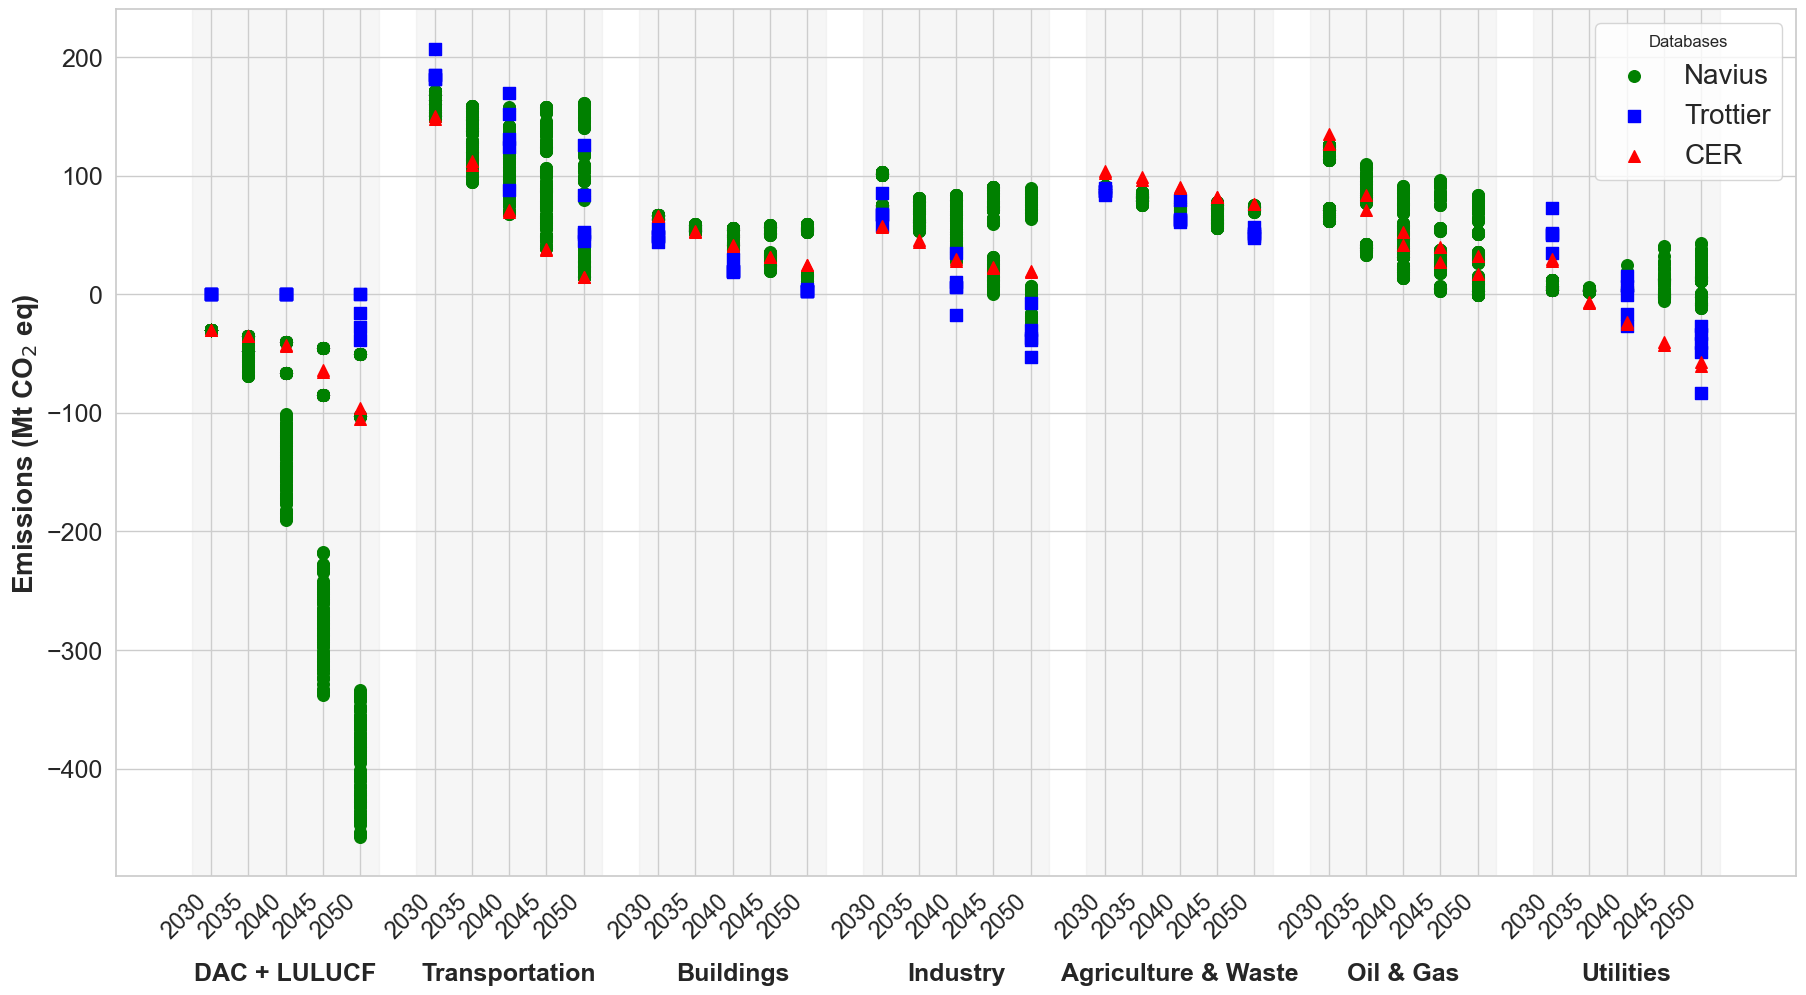

In [17]:
"""
Created on Wed Sep  4 00:53:56 2024

@author: fyabdulla
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'Final Analysis.xlsx'
xls = pd.ExcelFile(file_path)

# Define a dictionary to hold the data for each combination of database, year, and sector
data_dict = {}

# Define a function to process each sheet
def process_sheet(sheet_name, year_columns, sector_col='Sector'):
    # Load the sheet into a DataFrame
    df = pd.read_excel(xls, sheet_name=sheet_name)

    # For each year column, create a list of values for each sector and store them in the dictionary
    for year_col in year_columns:
        year = year_col.split(' ')[-1]  # Extract year (e.g., '2030', '2035')
        for sector in df[sector_col].unique():
            # Create a filtered DataFrame for the specific sector
            sector_data = df[df[sector_col] == sector][year_col].tolist()
            # Define the key for storing this data (e.g., 'Navius_2030_DAC')
            key = f'{sheet_name}_{year}_{sector}'
            # Store the data in the dictionary
            data_dict[key] = sector_data

# Process each sheet
process_sheet('Navius', ['Navius 2030', 'Navius 2035', 'Navius 2040', 'Navius 2045', 'Navius 2050'])
process_sheet('CD-Links', ['CD 2030', 'CD 2035', 'CD 2040', 'CD 2045', 'CD 2050'])
process_sheet('CER', ['CER 2030', 'CER 2035', 'CER 2040', 'CER 2045', 'CER 2050'])
process_sheet('Trottier', ['Trottier 2030', 'Trottier 2040', 'Trottier 2050'])

# Example of how the data is stored in the dictionary
# You can access the lists like this:
# Navius_2030_DAC = data_dict['Navius_2030_DAC']

# Example printing one of the data vectors
print(data_dict['Navius_2040_Agriculture & Waste'])  # Prints all DAC values for Navius 2030

# At this point, you have the data stored in data_dict. 
# You can use these lists for plotting, analysis, etc.

# Step 1: Define sectors and years
sectors = ['DAC + LULUCF', 'Transportation', 'Buildings', 'Industry', 'Agriculture & Waste', 'Oil & Gas', 'Utilities']
years = [2030, 2035, 2040, 2045, 2050]

# Step 2: Define colors for each database
database_colors = {
    'Navius': 'green',
    'Trottier': 'blue',
    'CD-Links': 'yellow',
    'CER': 'red'
}

# Step 3: Define marker styles for each database
database_markers = {
    'Navius': 'o',      # Circle
    'Trottier': 's',    # Square
    'CD-Links': 'D',         # Diamond
    'CER': '^'          # Triangle
}

# Step 4: Prepare the figure
fig, ax = plt.subplots(figsize=(18, 10))  # Increase size for better readability

# Step 5: Loop through the sectors and years to plot data
x_ticks = []
x_labels = []
x_index = 1  # Start from 1 for the first position in the x-axis
sector_positions = []  # To track the middle position of each sector group for sector labels
sector_spacing = 1  # Space between sectors

for sector in sectors:
    start_x_index = x_index  # To determine the middle for sector annotation
    
    # Add background color to sector groups for better distinction
    ax.axvspan(x_index - 0.5, x_index + len(years) - 0.5, color='lightgray', alpha=0.2)  # Light background color for each sector

    for year in years:
        # Create unique x position for each year within each sector
        x_ticks.append(x_index)
        x_labels.append(f'{year}')  # Only show year as x-ticks under each sector

        # Fetch data for the given sector and year from each database
        for db_name, color in database_colors.items():
            if db_name == 'CD-Links':
                continue  # Skip plotting CD-Links

            dict_key = f'{db_name}_{year}_{sector}'  # Format dict key
            if dict_key in data_dict:
                y_values = data_dict[dict_key]
                if len(y_values) > 0:
                    # Plot scatter points for the database (if values exist)
                    ax.scatter([x_index] * len(y_values), y_values, color=color, 
                               marker=database_markers[db_name], s=70,  # Adjust point size
                               label=db_name if x_index == 1 else "")  # Avoid repeating legend labels
                else:
                    print(f"No values to plot for {dict_key}")
            else:
                print(f"Key not found: {dict_key}")
        
        x_index += 1  # Move to the next x position
    
    # Calculate middle of year group for sector annotation
    end_x_index = x_index - 1
    mid_x_index = (start_x_index + end_x_index) / 2
    sector_positions.append(mid_x_index)
    
    # Add space between sectors
    x_index += sector_spacing  # Add extra space between the sectors

# Step 6: Customize the plot

# Set x-ticks and labels (only year labels now under the sectors)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=17)

# Adjust the sector label position further below the ticks
ymin, ymax = ax.get_ylim()
sector_label_y_offset = ymin - 0.12 * (ymax - ymin)  # 12% below the bottom of the axis


# Add sector labels below the year groups (below the x-axis) with bold and larger font
for i, sector in enumerate(sectors):
    ax.text(sector_positions[i], sector_label_y_offset, f'{sector.replace("_", " ")}', 
            ha='center', fontsize=18, weight='bold')

# Set y-label
ax.set_ylabel('Emissions (Mt CO$_2$ eq)', fontsize=20, fontweight='bold')

# Set title
#ax.set_title('Emissions Scatterplot by Sector, Year, and Database', fontsize=16, weight='bold')

# Add a legend with reduced markers size
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicates
ax.legend(by_label.values(), by_label.keys(), title="Databases", loc='upper right', fontsize=20)

# Show grid for easier reading
ax.grid(True)

# Adjust plot layout
plt.tight_layout()
plt.yticks(fontsize=18)

# Show the plot
plt.show()


Key not found: Trottier_2035_DAC + LULUCF
Key not found: Trottier_2045_DAC + LULUCF
Key not found: Trottier_2035_Transportation
Key not found: Trottier_2045_Transportation
Key not found: Trottier_2035_Buildings
Key not found: Trottier_2045_Buildings
Key not found: Trottier_2035_Industry
Key not found: Trottier_2045_Industry
Key not found: Trottier_2035_Agriculture & Waste
Key not found: Trottier_2045_Agriculture & Waste
Key not found: Trottier_2030_Oil & Gas
Key not found: Trottier_2035_Oil & Gas
Key not found: Trottier_2040_Oil & Gas
Key not found: Trottier_2045_Oil & Gas
Key not found: Trottier_2050_Oil & Gas
Key not found: Trottier_2035_Utilities
Key not found: Trottier_2045_Utilities


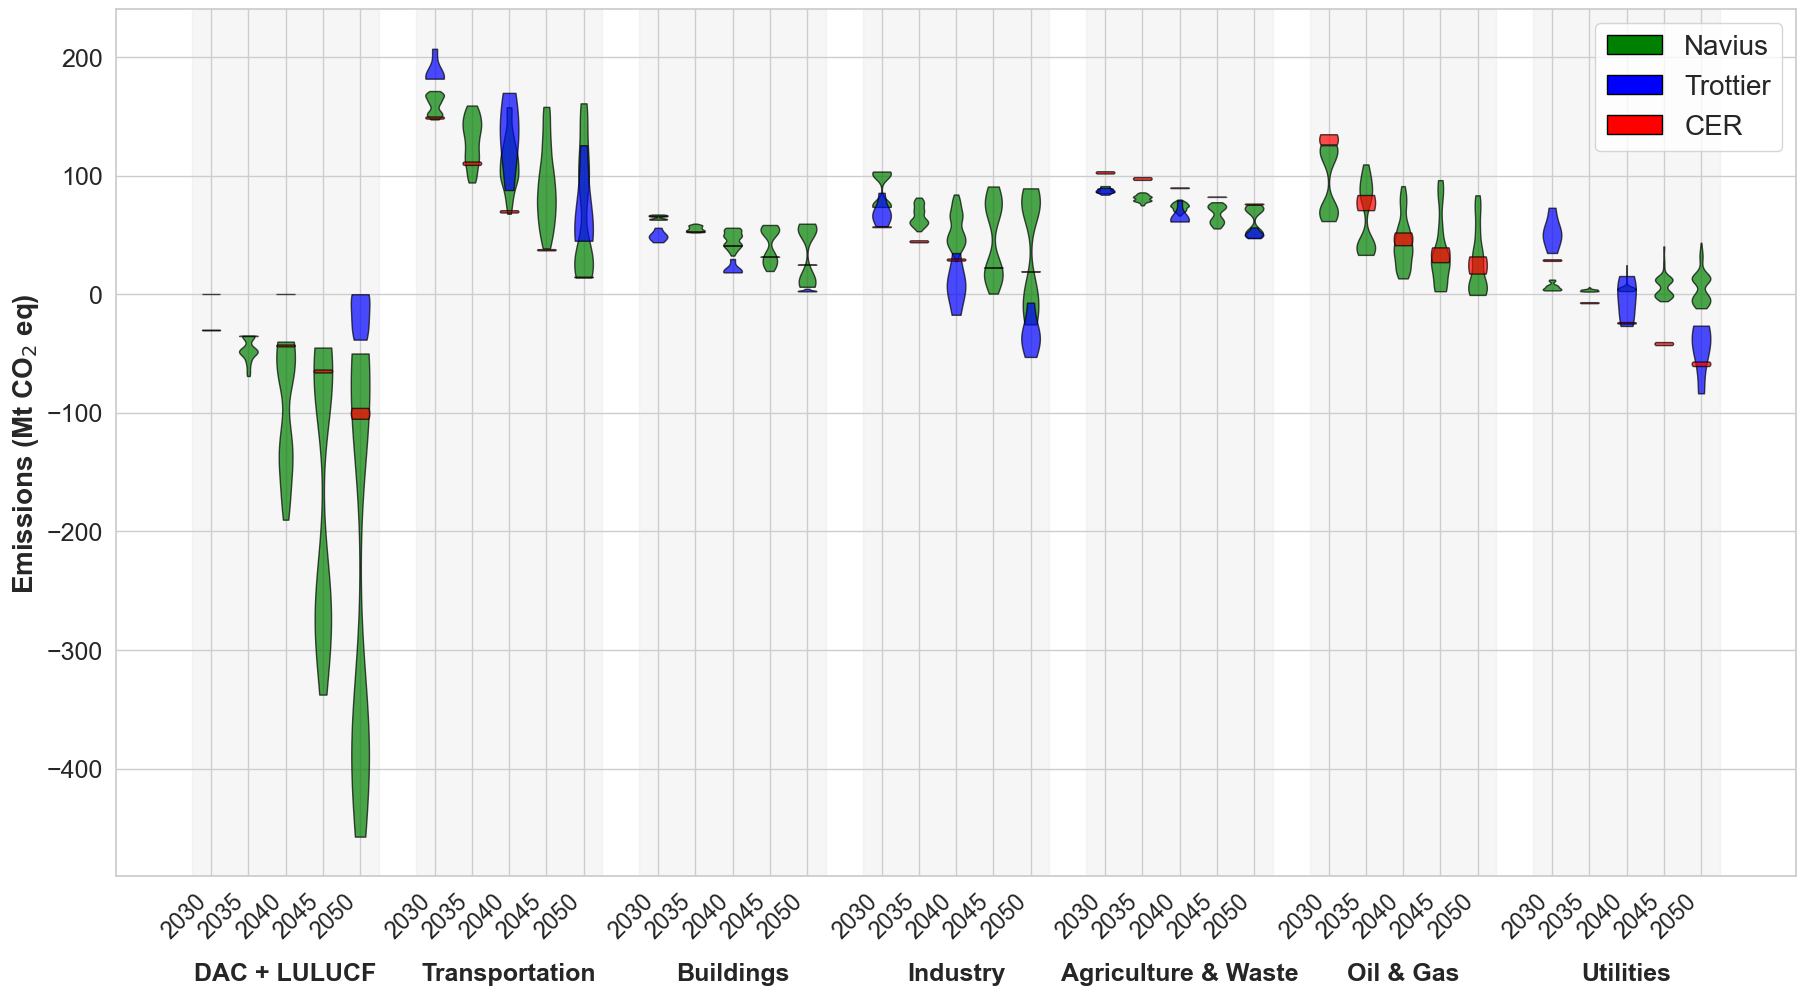

In [23]:
import seaborn as sns

# Step 4: Prepare the figure
fig, ax = plt.subplots(figsize=(18, 10))  # Increase size for better readability

x_ticks = []
x_labels = []
x_index = 1
sector_positions = []
sector_spacing = 1

for sector in sectors:
    start_x_index = x_index
    
    # Background shading for sector group
    ax.axvspan(x_index - 0.5, x_index + len(years) - 0.5, color='lightgray', alpha=0.2)

    for year in years:
        x_ticks.append(x_index)
        x_labels.append(f'{year}')
        
        for db_name, color in database_colors.items():
            if db_name == 'CD-Links':
                continue

            dict_key = f'{db_name}_{year}_{sector}'
            if dict_key in data_dict:
                y_values = data_dict[dict_key]
                if len(y_values) > 0:
                    vp = ax.violinplot(
                        dataset=y_values,
                        positions=[x_index],
                        showmeans=False,
                        showmedians=False,
                        showextrema=False
                    )
                    for pc in vp['bodies']:
                        pc.set_facecolor(color)
                        pc.set_edgecolor('black')
                        pc.set_alpha(0.7)
                else:
                    print(f"No values to plot for {dict_key}")
            else:
                print(f"Key not found: {dict_key}")
        
        x_index += 1
    
    end_x_index = x_index - 1
    mid_x_index = (start_x_index + end_x_index) / 2
    sector_positions.append(mid_x_index)
    
    x_index += sector_spacing

# Customize axes
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=17)

# Compute dynamic offset based on the y-axis range
ymin, ymax = ax.get_ylim()
sector_label_y_offset = ymin - 0.12 * (ymax - ymin)  # 12% below ymin

for i, sector in enumerate(sectors):
    ax.text(sector_positions[i], sector_label_y_offset, f'{sector.replace("_", " ")}',
            ha='center', fontsize=18, weight='bold')

# Y-label
ax.set_ylabel('Emissions (Mt CO$_2$ eq)', fontsize=20, fontweight='bold')

# Legend (manually add colored patches)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=db) 
    for db, color in database_colors.items() if db != 'CD-Links'
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=20)

ax.grid(True)
plt.tight_layout()
plt.yticks(fontsize=18)
plt.show()

